>>> Processing Data Center Size files...
   -> Size: 100.0 MW | Avg Yearly Direct Water: 50.2 MMGal
   -> Size: 200.0 MW | Avg Yearly Direct Water: 53.19 MMGal
   -> Size: 300.0 MW | Avg Yearly Direct Water: 55.45 MMGal
   -> Size: 400.0 MW | Avg Yearly Direct Water: 57.28 MMGal
   -> Size: 500.0 MW | Avg Yearly Direct Water: 58.94 MMGal


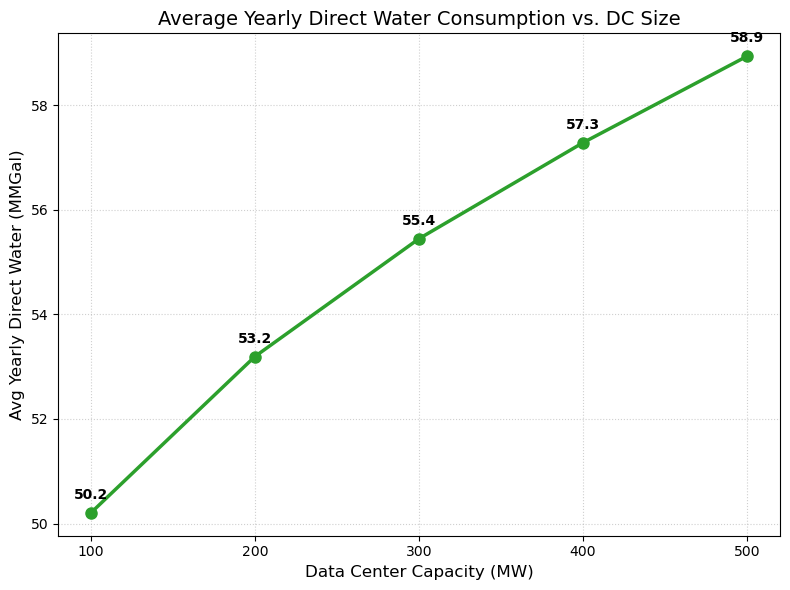

In [1]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration & Setup
# ==========================================
DC_Cap_base = 200.0
dc_multipliers = [0.50, 1.0, 1.5, 2.0, 2.5]
dc_sizes = DC_Cap_base .* dc_multipliers

# File list derived from the provided VS Code explorer image
files_info = [
    (dc_sizes[1], "Results_DCSize_1_50pct.xlsx"),
    (dc_sizes[2], "Results_DCSize_2_100pct.xlsx"),
    (dc_sizes[3], "Results_DCSize_3_150pct.xlsx"),
    (dc_sizes[4], "Results_DCSize_4_200pct.xlsx"),
    (dc_sizes[5], "Results_DCSize_5_250pct.xlsx")
]

println(">>> Processing Data Center Size files...")

# ==========================================
# 2. Data Extraction Logic
# ==========================================
function get_avg_yearly_direct_water(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return 0.0
    end
    
    xf = XLSX.readxlsx(filepath)
    if "Water_Consumption" ∉ XLSX.sheetnames(xf)
        return 0.0
    end
    
    df = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
    
    # Filter out the initial year 2025 to get accurate operational averages
    if "Year" in names(df)
        filter!(row -> row.Year != 2025, df)
    end
    
    n_years = nrow(df)
    if n_years == 0; return 0.0; end
    
    # Helper to find column index by partial string match (handles new MMGal headers automatically)
    function get_col_sum(name_part)
        c = findfirst(n -> occursin(lowercase(name_part), lowercase(string(n))), names(df))
        return isnothing(c) ? 0.0 : sum(coalesce.(df[!, c], 0.0))
    end
    
    # Target all direct water columns
    direct_keywords = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
    total_direct_water = sum(get_col_sum(k) for k in direct_keywords)
    
    # Return average yearly direct water
    return total_direct_water / n_years
end

# Extract data into array
avg_direct_waters = Float64[]

for (size, fname) in files_info
    avg_w = get_avg_yearly_direct_water(fname)
    push!(avg_direct_waters, avg_w)
    println("   -> Size: $size MW | Avg Yearly Direct Water: $(round(avg_w, digits=2)) MMGal")
end

# ==========================================
# 3. Plotting
# ==========================================
fig, ax = PyPlot.subplots(figsize=(8, 6))

# Plot Line and Markers
ax.plot(dc_sizes, avg_direct_waters, marker="o", linestyle="-", color="#2ca02c", linewidth=2.5, markersize=8, label="Direct Water")

# Add text annotations for each point
for i in 1:length(dc_sizes)
    ax.annotate(string(round(avg_direct_waters[i], digits=1)), 
                xy=(dc_sizes[i], avg_direct_waters[i]), 
                xytext=(0, 10), textcoords="offset points", ha="center", fontsize=10, fontweight="bold")
end

ax.set_title("Average Yearly Direct Water Consumption vs. DC Size", fontsize=14)
ax.set_xlabel("Data Center Capacity (MW)", fontsize=12)
ax.set_ylabel("Avg Yearly Direct Water (MMGal)", fontsize=12)
ax.grid(true, linestyle=":", alpha=0.6)

# Force X-axis ticks to match our exact tested capacities
ax.set_xticks(dc_sizes)

PyPlot.tight_layout()
display(fig)

>>> Processing Data Center Size files for Electricity...
   -> Size: 100.0 MW | Avg Yearly Electricity: 1005.6 GWh
   -> Size: 200.0 MW | Avg Yearly Electricity: 1604.3 GWh
   -> Size: 300.0 MW | Avg Yearly Electricity: 2202.6 GWh
   -> Size: 400.0 MW | Avg Yearly Electricity: 2800.6 GWh
   -> Size: 500.0 MW | Avg Yearly Electricity: 3398.6 GWh


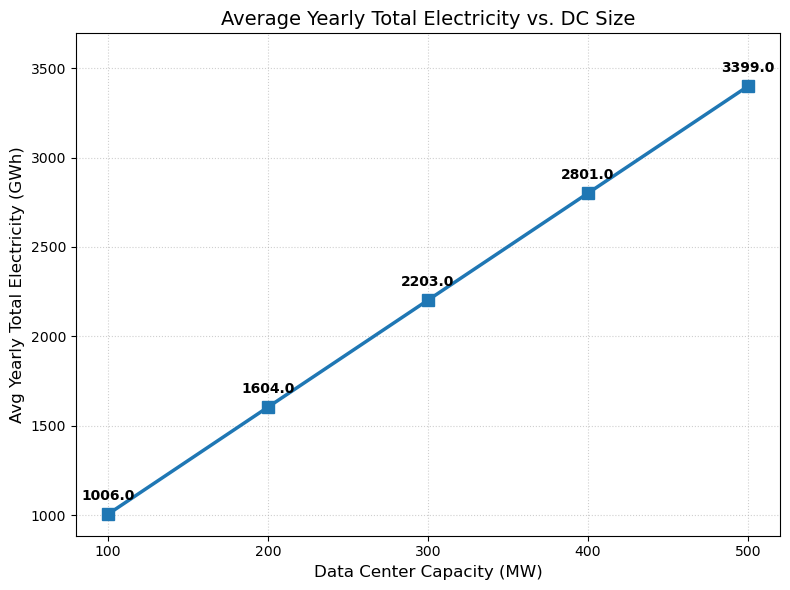

In [2]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration & Setup
# ==========================================
DC_Cap_base = 200.0
dc_multipliers = [0.50, 1.0, 1.5, 2.0, 2.5]
dc_sizes = DC_Cap_base .* dc_multipliers

# File list based on your parametric DC size runs
files_info = [
    (dc_sizes[1], "Results_DCSize_1_50pct.xlsx"),
    (dc_sizes[2], "Results_DCSize_2_100pct.xlsx"),
    (dc_sizes[3], "Results_DCSize_3_150pct.xlsx"),
    (dc_sizes[4], "Results_DCSize_4_200pct.xlsx"),
    (dc_sizes[5], "Results_DCSize_5_250pct.xlsx")
]

println(">>> Processing Data Center Size files for Electricity...")

# ==========================================
# 2. Data Extraction Logic
# ==========================================
function get_avg_yearly_electricity(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return 0.0
    end
    
    xf = XLSX.readxlsx(filepath)
    if "Generation_Summary" ∉ XLSX.sheetnames(xf)
        return 0.0
    end
    
    df = DataFrame(XLSX.gettable(xf["Generation_Summary"]))
    
    # Filter out the initial year 2025 to get accurate operational averages
    if "Year" in names(df)
        filter!(row -> row.Year != 2025, df)
    end
    
    n_years = nrow(df)
    if n_years == 0; return 0.0; end
    
    # Sum all columns except 'Year' to get total system generation (which equals total consumption)
    gen_cols = [c for c in names(df) if c != "Year"]
    total_elec_all_years = 0.0
    
    for c in gen_cols
        total_elec_all_years += sum(coalesce.(df[!, c], 0.0))
    end
    
    # Return average yearly total electricity (Values are already in GWh)
    return total_elec_all_years / n_years
end

# Extract data into array
avg_electricity = Float64[]

for (size, fname) in files_info
    avg_e = get_avg_yearly_electricity(fname)
    push!(avg_electricity, avg_e)
    println("   -> Size: $size MW | Avg Yearly Electricity: $(round(avg_e, digits=1)) GWh")
end

# ==========================================
# 3. Plotting
# ==========================================
fig, ax = PyPlot.subplots(figsize=(8, 6))

# Plot Line and Markers (Using a nice blue to contrast with the green water plot)
ax.plot(dc_sizes, avg_electricity, marker="s", linestyle="-", color="#1f77b4", linewidth=2.5, markersize=8, label="Total Electricity")

# Add text annotations for each point
for i in 1:length(dc_sizes)
    ax.annotate(string(round(avg_electricity[i], digits=0)), 
                xy=(dc_sizes[i], avg_electricity[i]), 
                xytext=(0, 10), textcoords="offset points", ha="center", fontsize=10, fontweight="bold")
end

ax.set_title("Average Yearly Total Electricity vs. DC Size", fontsize=14)
ax.set_xlabel("Data Center Capacity (MW)", fontsize=12)
ax.set_ylabel("Avg Yearly Total Electricity (GWh)", fontsize=12)
ax.grid(true, linestyle=":", alpha=0.6)

# Force X-axis ticks to match our exact tested capacities
ax.set_xticks(dc_sizes)

# Adjust Y-axis limits slightly to ensure annotations aren't cut off at the top
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max * 1.05)

PyPlot.tight_layout()
display(fig)